# Bayesian Decoding Diagnostics: Matilde Sessions

Pick a random MA session from `data/interim_matilde`, run the leave-one-lap-out Bayesian decoder at the Matilde behavior sampling rate of 100 Hz, and inspect the same diagnostic plots as the general Bayesian decoding notebook.

The decoder defaults to `DECODE_GROUPBY = "condway"`, which trains separate maps for each experimental block and direction. The Matilde adapter preserves repeated condition blocks such as `PO`, `PO`, and `PNO` as distinct `Cond` values. Keep `GROUP_CONDITION_FAMILIES = False` to compare those blocks separately. The decoded-vs-actual trace can show all condition-directions together or one selected `condway`. Position remains in the original Matilde coordinate scale by default, so decoding errors are interpretable in the source track units.

In [24]:
from dataclasses import replace
from pathlib import Path
from collections import Counter
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / 'src' / 'placefields').is_dir():
    repo_root = repo_root.parent
if not (repo_root / 'src' / 'placefields').is_dir():
    raise RuntimeError('Could not find repository root containing src/placefields')

sys.path.insert(0, str(repo_root / 'src'))

from placefields import (
    BayesianDecoderConfig,
    RatemapConfig,
    build_ratemap_from_trials,
    build_regular_xbin,
    build_trial_info_from_traj,
    canonical_condition_name,
    condition_family_name,
    cue_zone_layout_for_condition,
    decode_bayesian_position_from_trials,
    decode_condway,
    ifreq_swap,
    load_traj_condition_names,
    matlab_1b_to_python_0b,
    normalize_x_to_100,
)
from placefields.interim_io import (
    find_pairs,
    load_allcel_spikes,
    load_traj_fields,
    stitch_trial_series,
)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

repo_root

WindowsPath('C:/Users/tadse/OneDrive/Documenti/GitHub/CA1-cellclass')

In [25]:
# Session selection
INTERIM_ROOT = repo_root / 'data' / 'interim_matilde'
possible_sessions = ['MA104_2021-12-04_19-26-45', 'MA104_2021-12-05_21-20-36',
                     'MA104_2021-12-06_22-28-14', 'MA105_2021-12-20_18-03-05',
                     'MA105_2021-12-21_18-44-03', 'MA106_2022-01-06_21-02-42']  # sorted({p.parent.name for p in INTERIM_ROOT.glob('*/*/allcel_spikes.hdf5')})
SESSION_ID = possible_sessions[2]
print(SESSION_ID)         # e.g. 'MA104_2021-12-04_19-26-45'; empty means random
MIN_NEURONS = 0           # Only consider sessions with at least this many recorded cells
RANDOM_SEED = None       # Set an integer for reproducible random session selection
TRY_RANDOM_SESSIONS = 6     # If a random eligible MA session has no decodable windows, try another

# Decoder parameters
SPIKE_FREQ_HZ = 25_000.0
BEHAVIOR_FREQ_HZ = 100.0
TAU_S = 0.400
BIN_SIZE_CM = 4.0          # Matilde track spans about 0-192; 4-unit bins match the saved 50-bin summaries
MIN_SPEED = 2.0            # Set to None to disable speed filtering
DECODE_GROUPBY = 'condway'  # condway = condition + direction separated; condition/global are controls
GROUP_CONDITION_FAMILIES = False  # Keep repeated Matilde blocks such as PO, PO, and PNO separate
SMOOTH_SIGMA_BINS = 3.5
XBIN_REM = 0
MIN_VALID_WINDOW_FRACTION = 0.5
RATE_FLOOR_HZ = 1e-12
NORMALIZE_X_TO_100 = True  # Keep original Matilde position units; errors remain interpretable on the source scale

# Set to an integer for a faster draft run on large sessions; None uses all active cells.
MAX_CELLS = None

# Plot controls
TRACE_CONDWAY = 1       # None uses all condition-directions; set an int like 1 or 2 for one condway
TRACE_INCLUDE_PAIRED_DIRECTION = True  # If TRACE_CONDWAY is set, also show the matching W/B partner
MAX_TRACE_WINDOWS = 600     # None uses all selected decoded windows; paired directions are balanced below
BEHAVIOR_TRACE_STRIDE = 2    # Plot every nth 100 Hz behavior sample for the actual-position trace
TRACE_TIME_MODE = 'selected_trials'  # 'selected_trials' removes between-condition gaps; 'session' keeps absolute time
TRACE_TRIAL_GAP_S = 0.0      # Gap between selected trials when TRACE_TIME_MODE='selected_trials'
TRACE_FLIP_BACKWARD_FOR_DISPLAY = 'auto'  # 'auto' flips B on the plot if raw B laps increase in stored coordinates
TRACE_SHOW_CONDITION_BLOCKS = True  # Draw vertical separators and labels for condition blocks on the trace
MAX_POSTERIOR_WINDOWS = 250
MIN_BEST_LAP_WINDOWS = 10  # Minimum decoded windows required when selecting the lowest-error lap
N_RANDOM_HEATMAP_CELLS = 5
NEURON_HEATMAP_SEED = 13
ROW_NORMALIZE_NEURON_HEATMAPS = True

MA104_2021-12-06_22-28-14


In [26]:
def count_recorded_cells(allcel_path):
    with np.load(allcel_path, allow_pickle=False) as z:
        if 'allcel__id_cel' not in z.files:
            return None, f"missing allcel__id_cel; keys include: {', '.join(z.files[:6])}"
        return int(np.asarray(z['allcel__id_cel']).size), ''


def eligible_pairs(interim_root, min_neurons):
    rows = []
    skipped = []
    for session_id, allcel_path, traj_path in find_pairs(interim_root, set()):
        try:
            n_cells, reason = count_recorded_cells(allcel_path)
        except Exception as exc:
            n_cells, reason = None, str(exc)
        if n_cells is None:
            skipped.append((session_id, allcel_path, reason))
            continue
        if n_cells >= int(min_neurons):
            rows.append((session_id, allcel_path, traj_path, n_cells))
    if skipped:
        print(f'Skipped {len(skipped)} allcel files that do not match the expected decoder schema.')
        for session_id, allcel_path, reason in skipped[:5]:
            print(f'  {session_id}: {allcel_path.name} ({reason})')
        if len(skipped) > 5:
            print(f'  ... {len(skipped) - 5} more')
    return rows


def build_condition_name_map(traj_path):
    try:
        cond_raw, names_raw = load_traj_condition_names(traj_path)
    except Exception:
        return {}

    out = {}
    for cond in np.unique(cond_raw.astype(np.int64, copy=False)):
        names = [
            canonical_condition_name(name)
            for name in names_raw[cond_raw == cond].tolist()
            if canonical_condition_name(name)
        ]
        if not names:
            continue
        counts = Counter(names)
        out[int(cond)] = sorted(counts.items(), key=lambda kv: (-kv[1], kv[0]))[0][0]
    return out


def condition_label_for_condway(condway, condition_name_map):
    base_condition_1b, direction = decode_condway(int(condway))
    name = condition_name_map.get(int(base_condition_1b), f'cond{base_condition_1b}')
    return f'{name} {direction}'


def paired_direction_condway(condway):
    condway = int(condway)
    return condway + 1 if condway % 2 else condway - 1


def condition_name_for_condway(condway, condition_name_map):
    base_condition_1b, _ = decode_condway(int(condway))
    return condition_name_map.get(int(base_condition_1b), f'cond{base_condition_1b}')


def cue_layout_for_condway(condway, condition_name_map):
    name = condition_name_for_condway(condway, condition_name_map)
    layout = cue_zone_layout_for_condition(name, condition_family=condition_family_name(name))
    if layout.condition_family == 'PO':
        first_rich_span = layout.rich_spans[:1]
        first_start, first_stop = first_rich_span[0]
        object_centers = tuple(center for center in layout.object_centers if first_start <= center < first_stop)
        return replace(layout, rich_spans=first_rich_span, object_centers=object_centers)
    return layout


def draw_cue_zones_y(ax, layout, *, show_labels=False, style='spans'):
    if style not in {'spans', 'axis_marker'}:
        raise ValueError("style must be 'spans' or 'axis_marker'")
    for start, end in layout.poor_spans:
        if style == 'spans':
            ax.axhspan(start, end, color='tab:blue', alpha=0.035, lw=0, zorder=0)
        if show_labels:
            ax.text(0.005, 0.5 * (start + end), 'poor', transform=ax.get_yaxis_transform(), va='center', ha='left', color='tab:blue', fontsize=8, alpha=0.8)
    for start, end in layout.rich_spans:
        if style == 'spans':
            ax.axhspan(start, end, color='gold', alpha=0.14, lw=0, zorder=0)
        else:
            ax.plot([-0.012, -0.012], [start, end], transform=ax.get_yaxis_transform(), color='goldenrod', lw=6, solid_capstyle='butt', clip_on=False, zorder=5)
        if show_labels:
            ax.text(0.005, 0.5 * (start + end), 'rich', transform=ax.get_yaxis_transform(), va='center', ha='left', color='goldenrod', fontsize=8, alpha=0.9)
    if style == 'spans':
        for start, end in layout.excluded_spans:
            ax.axhspan(start, end, color='0.7', alpha=0.08, lw=0, zorder=0)
    for center in layout.object_centers:
        ax.axhline(center, color='black', ls='--', lw=1.1, alpha=0.75, zorder=1)


def draw_cue_zones_x(ax, layout, *, show_labels=False):
    for start, end in layout.poor_spans:
        ax.axvspan(start, end, color='tab:blue', alpha=0.035, lw=0, zorder=2)
        if show_labels:
            ax.text(0.5 * (start + end), 0.98, 'poor', transform=ax.get_xaxis_transform(), va='top', ha='center', color='tab:blue', fontsize=8, alpha=0.8)
    for start, end in layout.rich_spans:
        ax.axvspan(start, end, color='gold', alpha=0.14, lw=0, zorder=2)
        if show_labels:
            ax.text(0.5 * (start + end), 0.98, 'rich', transform=ax.get_xaxis_transform(), va='top', ha='center', color='goldenrod', fontsize=8, alpha=0.9)
    for start, end in layout.excluded_spans:
        ax.axvspan(start, end, color='0.7', alpha=0.08, lw=0, zorder=2)
    for center in layout.object_centers:
        ax.axvline(center, color='black', ls='--', lw=1.1, alpha=0.75, zorder=3)


def run_decoder_for_pair(session_id, allcel_path, traj_path):
    itime_25k, id_spk, id_cel = load_allcel_spikes(allcel_path)
    cond, wb, start, stop, vr_list, speed_list = load_traj_fields(traj_path)
    condition_name_map = build_condition_name_map(traj_path)

    x = stitch_trial_series(start, stop, vr_list)
    if NORMALIZE_X_TO_100:
        x = normalize_x_to_100(x)

    if speed_list is None and MIN_SPEED is not None:
        raise ValueError('No XSpeed/Speed field; set MIN_SPEED=None to decode without speed filtering')
    speed = stitch_trial_series(start, stop, speed_list) if speed_list is not None else None

    trials = build_trial_info_from_traj(
        cond=cond,
        wb=wb,
        start_1b=start,
        stop_1b=stop,
        n_samples=int(x.size),
    )
    spike_idx_1b = ifreq_swap(itime_25k, SPIKE_FREQ_HZ, BEHAVIOR_FREQ_HZ)
    spike_idx_0b = matlab_1b_to_python_0b(spike_idx_1b)

    cell_ids = np.asarray(id_cel, dtype=np.int64).ravel()
    if MAX_CELLS is not None:
        cell_ids = cell_ids[: int(MAX_CELLS)]

    xbin_edges = build_regular_xbin(x, BIN_SIZE_CM)
    cfg = BayesianDecoderConfig(
        freq_hz=BEHAVIOR_FREQ_HZ,
        tau_s=TAU_S,
        bin_size_cm=BIN_SIZE_CM,
        min_speed=MIN_SPEED,
        smooth_sigma_bins=SMOOTH_SIGMA_BINS,
        xbin_rem=XBIN_REM,
        min_valid_window_fraction=MIN_VALID_WINDOW_FRACTION,
        rate_floor_hz=RATE_FLOOR_HZ,
        decode_groupby=DECODE_GROUPBY,
        group_condition_families=GROUP_CONDITION_FAMILIES,
    )
    result = decode_bayesian_position_from_trials(
        position_x=x,
        spike_indices_0b=spike_idx_0b,
        spike_cell_ids=id_spk,
        cell_ids=cell_ids,
        trials=trials,
        xbin_edges=xbin_edges,
        cfg=cfg,
        speed=speed,
        condition_names_by_base=condition_name_map,
    )
    context = {
        'session_id': session_id,
        'allcel_path': allcel_path,
        'traj_path': traj_path,
        'position_x': x,
        'speed': speed,
        'trials': trials,
        'spike_idx_0b': spike_idx_0b,
        'id_spk': id_spk,
        'id_cel': id_cel,
        'xbin_edges_full': xbin_edges,
        'condition_name_map': condition_name_map,
        'n_cells_available': int(np.asarray(id_cel).size),
        'n_cells_requested': int(cell_ids.size),
    }
    return result, context


def result_to_frame(result):
    return pd.DataFrame(
        {
            'trial_index': result.trial_index_w,
            'condway': result.condway_w,
            'base_condition': [decode_condway(condway)[0] for condway in result.condway_w],
            'direction': [decode_condway(condway)[1] for condway in result.condway_w],
            'window_start': result.window_start_w,
            'window_stop': result.window_stop_w,
            'window_mid_s': 0.5 * (result.window_start_w + result.window_stop_w) / BEHAVIOR_FREQ_HZ,
            'actual_x': result.actual_x_w,
            'decoded_x': result.decoded_x_w,
            'actual_bin': result.actual_bin_w,
            'decoded_bin': result.decoded_bin_w,
            'error_cm': result.error_cm_w,
            'prob_actual': result.prob_actual_w,
            'n_spikes': result.n_spikes_w,
            'n_train_laps': result.n_train_laps_w,
            'train_group': result.train_group_w,
            'train_group_label': result.train_group_label_w.astype(str),
        }
    )


def behavior_trace_frame_for_condways(context, condways, stride=5, trial_gap_s=0.0):
    x = np.asarray(context['position_x'], dtype=float)
    trials = context['trials']
    condways = {int(condway) for condway in condways}
    stride = max(1, int(stride))
    trial_gap_s = max(0.0, float(trial_gap_s))
    condition_name_map = context.get('condition_name_map', {})
    frames = []
    selected_offset_s = 0.0
    for trial in trials:
        if int(trial.condway) not in condways:
            continue
        start = max(0, int(trial.start_idx_0b))
        stop = min(int(x.size), int(trial.stop_idx_0b_exclusive))
        if stop <= start:
            continue
        sample_index = np.arange(start, stop, stride, dtype=np.int64)
        position = x[sample_index]
        keep = np.isfinite(position)
        sample_index = sample_index[keep]
        position = position[keep]
        if sample_index.size == 0:
            continue
        base_condition, direction = decode_condway(int(trial.condway))
        condition_name = condition_name_map.get(int(base_condition), f'cond{base_condition}')
        trial_time_s = (sample_index - start) / BEHAVIOR_FREQ_HZ
        frames.append(
            pd.DataFrame(
                {
                    'trial_index': int(trial.trial_index),
                    'condway': int(trial.condway),
                    'base_condition': int(base_condition),
                    'condition_name': condition_name,
                    'condition_label': f'{condition_name} {direction}',
                    'direction': direction,
                    'trial_start_index': start,
                    'trial_stop_index': stop,
                    'selected_offset_s': selected_offset_s,
                    'sample_index': sample_index,
                    'session_time_s': sample_index / BEHAVIOR_FREQ_HZ,
                    'trial_time_s': trial_time_s,
                    'selected_time_s': selected_offset_s + trial_time_s,
                    'position_x': position,
                }
            )
        )
        selected_offset_s += (stop - start) / BEHAVIOR_FREQ_HZ + trial_gap_s
    columns = [
        'trial_index', 'condway', 'base_condition', 'condition_name', 'condition_label',
        'direction', 'trial_start_index', 'trial_stop_index',
        'selected_offset_s', 'sample_index', 'session_time_s', 'trial_time_s',
        'selected_time_s', 'position_x',
    ]
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(columns=columns)


def resolve_backward_common_axis_flip(deltas, setting='auto'):
    if isinstance(setting, str):
        normalized = setting.strip().lower()
        if normalized in {'false', 'no', '0'}:
            return False
        if normalized in {'true', 'yes', '1'}:
            return True
        if normalized != 'auto':
            raise ValueError("TRACE_FLIP_BACKWARD_FOR_DISPLAY must be 'auto', True, or False")
        delta_values = np.asarray(deltas, dtype=float)
        delta_values = delta_values[np.isfinite(delta_values)]
        return bool(delta_values.size and np.nanmedian(delta_values) > 0)
    return bool(setting)


def should_flip_backward_for_display(behavior_df, setting='auto'):
    b_df = behavior_df[behavior_df['direction'] == 'B']
    deltas = b_df.groupby('trial_index', sort=False)['position_x'].agg(lambda values: values.iloc[-1] - values.iloc[0])
    return resolve_backward_common_axis_flip(deltas.to_numpy(dtype=float), setting)


def should_flip_backward_for_context(context, setting='auto'):
    x = np.asarray(context['position_x'], dtype=float)
    deltas = []
    for trial in context['trials']:
        _, direction = decode_condway(int(trial.condway))
        if direction != 'B':
            continue
        start = max(0, int(trial.start_idx_0b))
        stop = min(int(x.size), int(trial.stop_idx_0b_exclusive))
        position = x[start:stop]
        position = position[np.isfinite(position)]
        if position.size >= 2:
            deltas.append(float(position[-1] - position[0]))
    return resolve_backward_common_axis_flip(deltas, setting)


def positions_on_common_axis(values, directions, *, x_min, x_max, flip_backward):
    out = np.asarray(values, dtype=float).copy()
    if not flip_backward:
        return out
    direction_values = np.asarray(directions).astype(str)
    if direction_values.ndim == 0:
        if str(direction_values.item()).upper() == 'B':
            out = float(x_min) + float(x_max) - out
        return out
    is_backward = np.char.upper(direction_values) == 'B'
    if is_backward.shape != out.shape:
        is_backward = np.broadcast_to(is_backward, out.shape)
    out[is_backward] = float(x_min) + float(x_max) - out[is_backward]
    return out


def spatial_array_on_common_axis(values, direction, *, flip_backward, axis=-1):
    out = np.asarray(values)
    if flip_backward and str(direction).upper() == 'B':
        return np.flip(out, axis=axis)
    return out


def condition_blocks_for_trace(behavior_df):
    if behavior_df.empty:
        return pd.DataFrame(columns=['condition_name', 'start_s', 'stop_s', 'n_laps'])
    laps = (
        behavior_df.sort_values(['plot_time_s', 'sample_index'])
        .groupby('trial_index', sort=False)
        .agg(
            condition_name=('condition_name', 'first'),
            start_s=('plot_time_s', 'min'),
            stop_s=('plot_time_s', 'max'),
        )
        .reset_index()
    )
    blocks = []
    current = None
    for row in laps.itertuples(index=False):
        if current is None or row.condition_name != current['condition_name']:
            if current is not None:
                blocks.append(current)
            current = {
                'condition_name': row.condition_name,
                'start_s': float(row.start_s),
                'stop_s': float(row.stop_s),
                'n_laps': 1,
            }
        else:
            current['stop_s'] = float(row.stop_s)
            current['n_laps'] += 1
    if current is not None:
        blocks.append(current)
    return pd.DataFrame(blocks)


def draw_condition_blocks_on_trace(ax, blocks):
    if blocks.empty:
        return
    x0, x1 = ax.get_xlim()
    min_label_width = 0.035 * max(1e-9, x1 - x0)
    for i, block in blocks.reset_index(drop=True).iterrows():
        start_s = float(block['start_s'])
        stop_s = float(block['stop_s'])
        if i > 0:
            ax.axvline(start_s, color='0.45', ls=':', lw=1.1, alpha=0.85, zorder=6)
        if stop_s - start_s >= min_label_width:
            ax.text(
                0.5 * (start_s + stop_s),
                0.985,
                str(block['condition_name']),
                transform=ax.get_xaxis_transform(),
                ha='center',
                va='top',
                fontsize=8,
                color='0.25',
                zorder=7,
            )

In [27]:
pairs = eligible_pairs(INTERIM_ROOT, MIN_NEURONS)
if not pairs:
    raise RuntimeError(f'No paired sessions with at least {MIN_NEURONS} cells under {INTERIM_ROOT}')

if SESSION_ID:
    candidates = [p for p in pairs if p[0] == SESSION_ID]
    if not candidates:
        n_found = 0
        for sid, allcel_path, _, _ in find_pairs(INTERIM_ROOT, set()):
            if sid == SESSION_ID:
                n_found, _ = count_recorded_cells(allcel_path)
                n_found = 0 if n_found is None else int(n_found)
                break
        raise RuntimeError(f'SESSION_ID not found among sessions with >= {MIN_NEURONS} cells: {SESSION_ID} (found {n_found})')
else:
    rng = np.random.default_rng(RANDOM_SEED)
    order = rng.permutation(len(pairs))[: min(TRY_RANDOM_SESSIONS, len(pairs))]
    candidates = [pairs[int(i)] for i in order]

last_error = None
result = None
context = None
for session_id, allcel_path, traj_path, n_cells in candidates:
    print(f'Trying {session_id} ({n_cells} cells)')
    try:
        result, context = run_decoder_for_pair(session_id, allcel_path, traj_path)
        if result.posterior_wx.shape[0] == 0:
            raise RuntimeError('decoder returned zero windows')
        min_used_cells = min(int(MIN_NEURONS), int(context['n_cells_requested']))
        if result.cell_ids.size < min_used_cells:
            raise RuntimeError(f'decoder used only {result.cell_ids.size} active cells after filtering')
        break
    except Exception as exc:
        last_error = exc
        print(f'  skipped: {exc}')
        result = None
        context = None

if result is None or context is None:
    raise RuntimeError(f'No decodable session found in candidate set. Last error: {last_error}')

decode_df = result_to_frame(result)
condition_name_map = context['condition_name_map']
decode_df['condition_label'] = [
    condition_label_for_condway(condway, condition_name_map)
    for condway in decode_df['condway'].to_numpy()
]
print('\nSelected session:', context['session_id'])
print('allcel:', context['allcel_path'])
print('trajdata:', context['traj_path'])
print('cells available/requested/used:', context['n_cells_available'], context['n_cells_requested'], result.cell_ids.size)
print('trials/windows/bins:', len(context['trials']), result.posterior_wx.shape[0], result.xbin_centers.size)
print('decode grouping:', DECODE_GROUPBY, '| family pooled:', GROUP_CONDITION_FAMILIES)
print('posterior row-sum range:', np.sum(result.posterior_wx, axis=1).min(), np.sum(result.posterior_wx, axis=1).max())
print('condition labels:', sorted(decode_df['condition_label'].unique().tolist()))

Trying MA104_2021-12-06_22-28-14 (49 cells)

Selected session: MA104_2021-12-06_22-28-14
allcel: C:\Users\tadse\OneDrive\Documenti\GitHub\CA1-cellclass\data\interim_matilde\MA104\2021-12-06\MA104_2021-12-06_22-28-14_allcel.npz
trajdata: C:\Users\tadse\OneDrive\Documenti\GitHub\CA1-cellclass\data\interim_matilde\MA104\2021-12-06\MA104_2021-12-06_22-28-14_trajdata.npz
cells available/requested/used: 49 49 49
trials/windows/bins: 68 1563 25
decode grouping: condway | family pooled: False
posterior row-sum range: 0.9999999999999997 1.0000000000000004
condition labels: ['PNO B', 'PNO W', 'PO B', 'PO W']


In [28]:
summary = (
    decode_df.groupby(['condway', 'condition_label'], sort=True)
    .agg(
        n_windows=('error_cm', 'size'),
        n_laps_decoded=('trial_index', 'nunique'),
        median_error_cm=('error_cm', 'median'),
        mean_error_cm=('error_cm', 'mean'),
        mean_prob_actual=('prob_actual', 'mean'),
        mean_spikes_per_window=('n_spikes', 'mean'),
        train_group_label=('train_group_label', lambda s: ','.join(sorted(set(s.astype(str))))),
    )
    .reset_index()
)
display(summary)

,condway,condition_label,n_windows,n_laps_decoded,median_error_cm,mean_error_cm,mean_prob_actual,mean_spikes_per_window,train_group_label
0,1,PO W,271,12,7.284998,15.202614,0.137367,92.022140,PO W
1,2,PO B,305,12,7.540992,14.431827,0.149059,97.501639,PO B
2,3,PO W,259,12,13.106629,20.969925,0.082654,57.297297,PO W
3,4,PO B,279,12,9.444602,19.086995,0.119864,63.645161,PO B
4,5,PNO W,241,10,20.850615,26.129886,0.057313,48.713693,PNO W
5,6,PNO B,208,10,18.765089,23.271846,0.084703,62.701923,PNO B


## Decoded Versus Actual Position

The actual-position trace is drawn from the raw behavior samples for the selected trials; decoded positions are overlaid only where the decoder produced windows. `TRACE_TIME_MODE='selected_trials'` concatenates the selected laps to avoid between-condition gaps. Condition blocks are marked with vertical dotted lines and labels when `TRACE_SHOW_CONDITION_BLOCKS=True`. Set `TRACE_CONDWAY` above to an integer to plot one condition-direction; with `TRACE_INCLUDE_PAIRED_DIRECTION = True`, the matching forward/backward partner is included too.

,condway,condition_label,direction,n_windows,n_decoded_laps,n_behavior_laps,n_behavior_samples
0,1,PO W,W,271,12,12,7958
1,2,PO B,B,305,12,12,9179


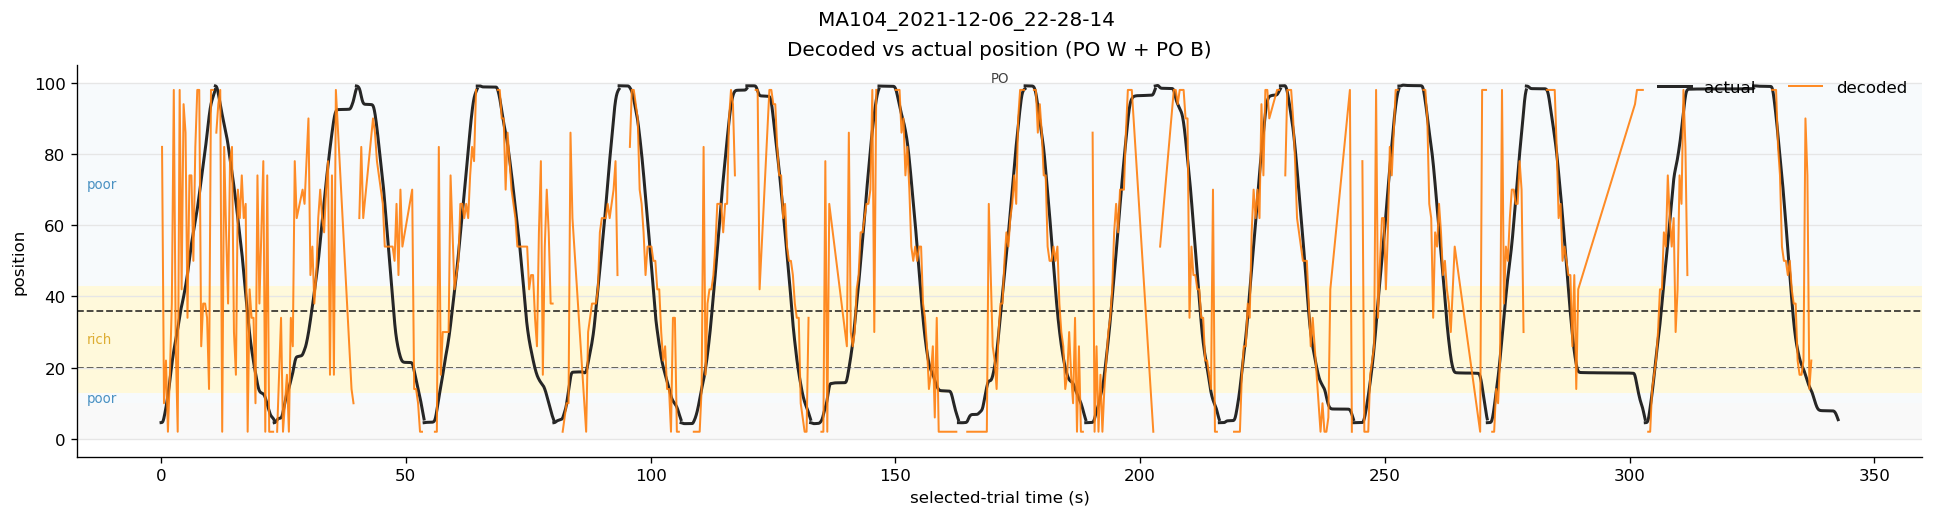

C:\Users\tadse\AppData\Local\Temp\ipykernel_20228\2360354167.py:163: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[2].boxplot(groups, labels=labels, showfliers=True)


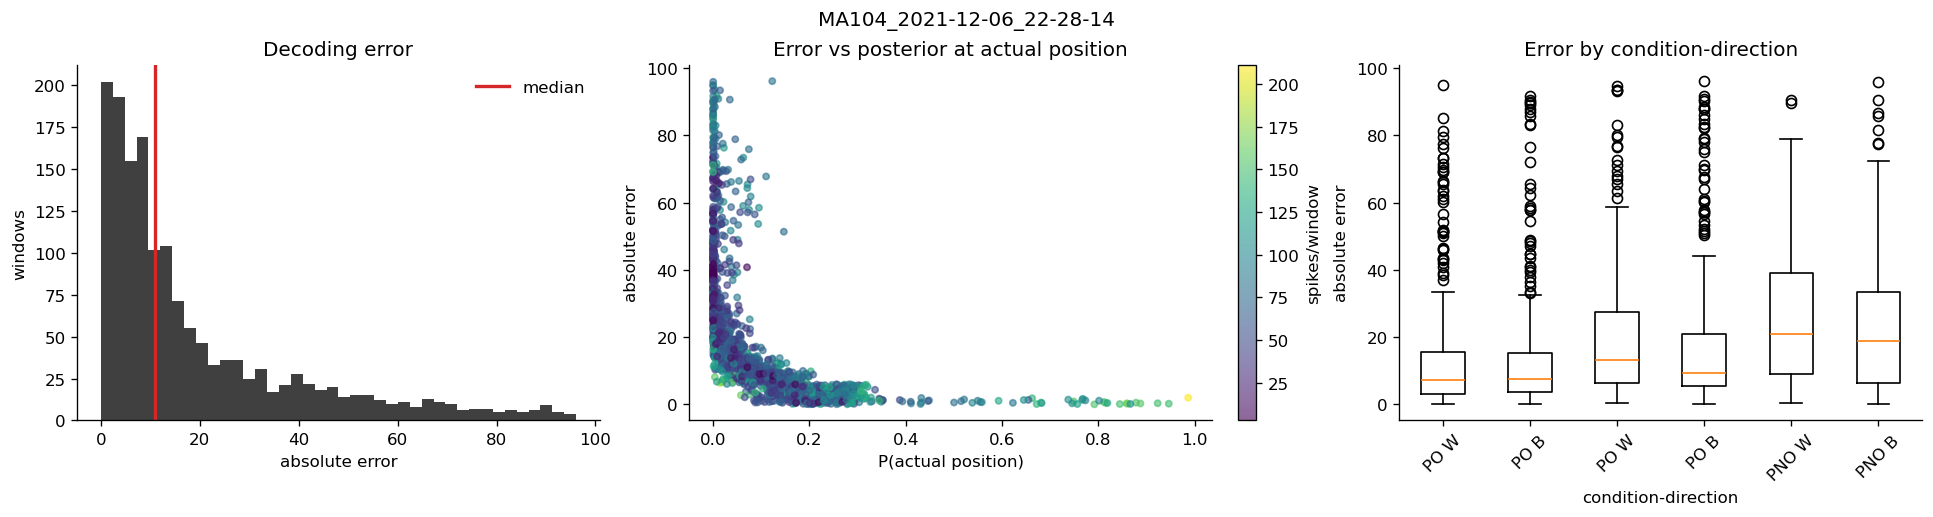

In [29]:
if 'direction' not in decode_df.columns:
    decode_df['base_condition'] = [decode_condway(condway)[0] for condway in decode_df['condway'].to_numpy()]
    decode_df['direction'] = [decode_condway(condway)[1] for condway in decode_df['condway'].to_numpy()]

if TRACE_CONDWAY is None:
    trace_condways = sorted(decode_df['condway'].unique().astype(int).tolist())
else:
    trace_condways = [int(TRACE_CONDWAY)]
    if TRACE_INCLUDE_PAIRED_DIRECTION:
        trace_condways.append(paired_direction_condway(int(TRACE_CONDWAY)))
    available_condways = set(decode_df['condway'].unique().astype(int).tolist())
    trace_condways = [condway for condway in sorted(set(trace_condways)) if condway in available_condways]

trace_source = decode_df[decode_df['condway'].isin(trace_condways)]
if trace_source.empty:
    raise RuntimeError(f'No decoded windows for TRACE_CONDWAY={TRACE_CONDWAY}; requested condways={trace_condways}')
behavior_trace_df = behavior_trace_frame_for_condways(
    context,
    trace_condways,
    stride=BEHAVIOR_TRACE_STRIDE,
    trial_gap_s=TRACE_TRIAL_GAP_S,
)
if behavior_trace_df.empty:
    raise RuntimeError(f'No behavior samples for TRACE_CONDWAY={TRACE_CONDWAY}; requested condways={trace_condways}')

behavior_counts = (
    behavior_trace_df.groupby('condway', sort=True)
    .agg(n_behavior_laps=('trial_index', 'nunique'), n_behavior_samples=('sample_index', 'size'))
    .reset_index()
)
trace_counts = (
    trace_source.groupby(['condway', 'condition_label', 'direction'], sort=True)
    .agg(n_windows=('error_cm', 'size'), n_decoded_laps=('trial_index', 'nunique'))
    .reset_index()
    .merge(behavior_counts, on='condway', how='left')
)
trace_counts[['n_behavior_laps', 'n_behavior_samples']] = trace_counts[['n_behavior_laps', 'n_behavior_samples']].fillna(0).astype(int)
display(trace_counts)

plot_df = trace_source.sort_values('window_start').reset_index(drop=True)
if MAX_TRACE_WINDOWS is None:
    trace_df = plot_df
elif TRACE_CONDWAY is not None and len(trace_condways) > 1:
    n_per_condway = max(1, int(np.ceil(MAX_TRACE_WINDOWS / len(trace_condways))))
    trace_df = (
        plot_df.groupby('condway', sort=False, group_keys=False)
        .head(n_per_condway)
        .sort_values('window_start')
        .reset_index(drop=True)
    )
else:
    trace_df = plot_df.iloc[: min(MAX_TRACE_WINDOWS, len(plot_df))]
trace_df = trace_df.copy()

trace_time_mode = str(TRACE_TIME_MODE).strip().lower()
if trace_time_mode not in {'selected_trials', 'session'}:
    raise ValueError("TRACE_TIME_MODE must be 'selected_trials' or 'session'")
trial_lookup = behavior_trace_df[
    ['trial_index', 'trial_start_index', 'selected_offset_s']
].drop_duplicates('trial_index')
trace_df = trace_df.merge(trial_lookup, on='trial_index', how='left')
if trace_df['trial_start_index'].isna().any():
    missing = trace_df.loc[trace_df['trial_start_index'].isna(), 'trial_index'].unique().tolist()
    raise RuntimeError(f'Decoded windows refer to trials missing from behavior trace: {missing[:10]}')

if trace_time_mode == 'selected_trials':
    behavior_trace_df['plot_time_s'] = behavior_trace_df['selected_time_s']
    trace_df['plot_time_s'] = trace_df['selected_offset_s'] + (
        0.5 * (trace_df['window_start'] + trace_df['window_stop']) - trace_df['trial_start_index']
    ) / BEHAVIOR_FREQ_HZ
    trace_xlabel = 'selected-trial time (s)'
else:
    behavior_trace_df['plot_time_s'] = behavior_trace_df['session_time_s']
    trace_df['plot_time_s'] = trace_df['window_mid_s']
    trace_xlabel = 'session time (s)'

x_min = float(np.nanmin(context['xbin_edges_full']))
x_max = float(np.nanmax(context['xbin_edges_full']))
flip_backward = should_flip_backward_for_context(context, TRACE_FLIP_BACKWARD_FOR_DISPLAY)
behavior_trace_df['plot_position_x'] = positions_on_common_axis(
    behavior_trace_df['position_x'], behavior_trace_df['direction'], x_min=x_min, x_max=x_max, flip_backward=flip_backward
)
trace_df['plot_decoded_x'] = positions_on_common_axis(
    trace_df['decoded_x'], trace_df['direction'], x_min=x_min, x_max=x_max, flip_backward=flip_backward
)
trace_label = (
    'all condition-directions'
    if TRACE_CONDWAY is None
    else ' + '.join(condition_label_for_condway(condway, condition_name_map) for condway in trace_condways)
)

fig_trace, ax_trace = plt.subplots(figsize=(16, 4.2), constrained_layout=True)
trace_families = {
    condition_family_name(condition_name_for_condway(condway, condition_name_map))
    for condway in trace_condways
}
if NORMALIZE_X_TO_100 and len(trace_families) == 1:
    draw_cue_zones_y(
        ax_trace,
        cue_layout_for_condway(int(trace_condways[0]), condition_name_map),
        show_labels=True,
    )
used_labels = set()
for _, trial_df in behavior_trace_df.groupby('trial_index', sort=False):
    ax_trace.plot(
        trial_df['plot_time_s'],
        trial_df['plot_position_x'],
        lw=1.8,
        color='0.15',
        label='actual' if 'actual' not in used_labels else None,
        zorder=3,
    )
    used_labels.add('actual')
for _, trial_df in trace_df.groupby('trial_index', sort=False):
    ax_trace.plot(
        trial_df['plot_time_s'],
        trial_df['plot_decoded_x'],
        lw=1.2,
        color='tab:orange',
        alpha=0.9,
        label='decoded' if 'decoded' not in used_labels else None,
        zorder=4,
    )
    used_labels.add('decoded')
if TRACE_SHOW_CONDITION_BLOCKS:
    condition_blocks = condition_blocks_for_trace(behavior_trace_df)
    draw_condition_blocks_on_trace(ax_trace, condition_blocks)
flip_note = '; B displayed on common axis' if flip_backward else ''
ax_trace.set_title(f'Decoded vs actual position ({trace_label}{flip_note})')
ax_trace.set_xlabel(trace_xlabel)
ax_trace.set_ylabel('position')
ax_trace.legend(frameon=False, ncol=2, loc='upper right')
ax_trace.grid(axis='y', color='0.9', lw=0.8)
fig_trace.suptitle(context['session_id'])
plt.show()

fig_diag, axs = plt.subplots(1, 3, figsize=(16, 4.2), constrained_layout=True)

axs[0].hist(decode_df['error_cm'], bins=40, color='0.25')
axs[0].axvline(decode_df['error_cm'].median(), color='tab:red', lw=2, label='median')
axs[0].set_title('Decoding error')
axs[0].set_xlabel('absolute error')
axs[0].set_ylabel('windows')
axs[0].legend(frameon=False)

sc = axs[1].scatter(
    decode_df['prob_actual'],
    decode_df['error_cm'],
    c=decode_df['n_spikes'],
    s=14,
    alpha=0.6,
    cmap='viridis',
)
axs[1].set_title('Error vs posterior at actual position')
axs[1].set_xlabel('P(actual position)')
axs[1].set_ylabel('absolute error')
fig_diag.colorbar(sc, ax=axs[1], label='spikes/window')

error_groups = list(decode_df.groupby(['condway', 'condition_label'], sort=True))
groups = [g['error_cm'].to_numpy() for _, g in error_groups]
labels = [label for (_, label), _ in error_groups]
axs[2].boxplot(groups, labels=labels, showfliers=True)
axs[2].set_title('Error by condition-direction')
axs[2].set_xlabel('condition-direction')
axs[2].set_ylabel('absolute error')
axs[2].tick_params(axis='x', rotation=45)

fig_diag.suptitle(context['session_id'])
plt.show()

## Random Neuron Heatmaps By Condition-Direction

This builds ratemaps with the same binning and speed settings as the decoder and plots 5 random active decoded neurons. Rows are neurons, columns are spatial bins, and each panel is one condition-direction.

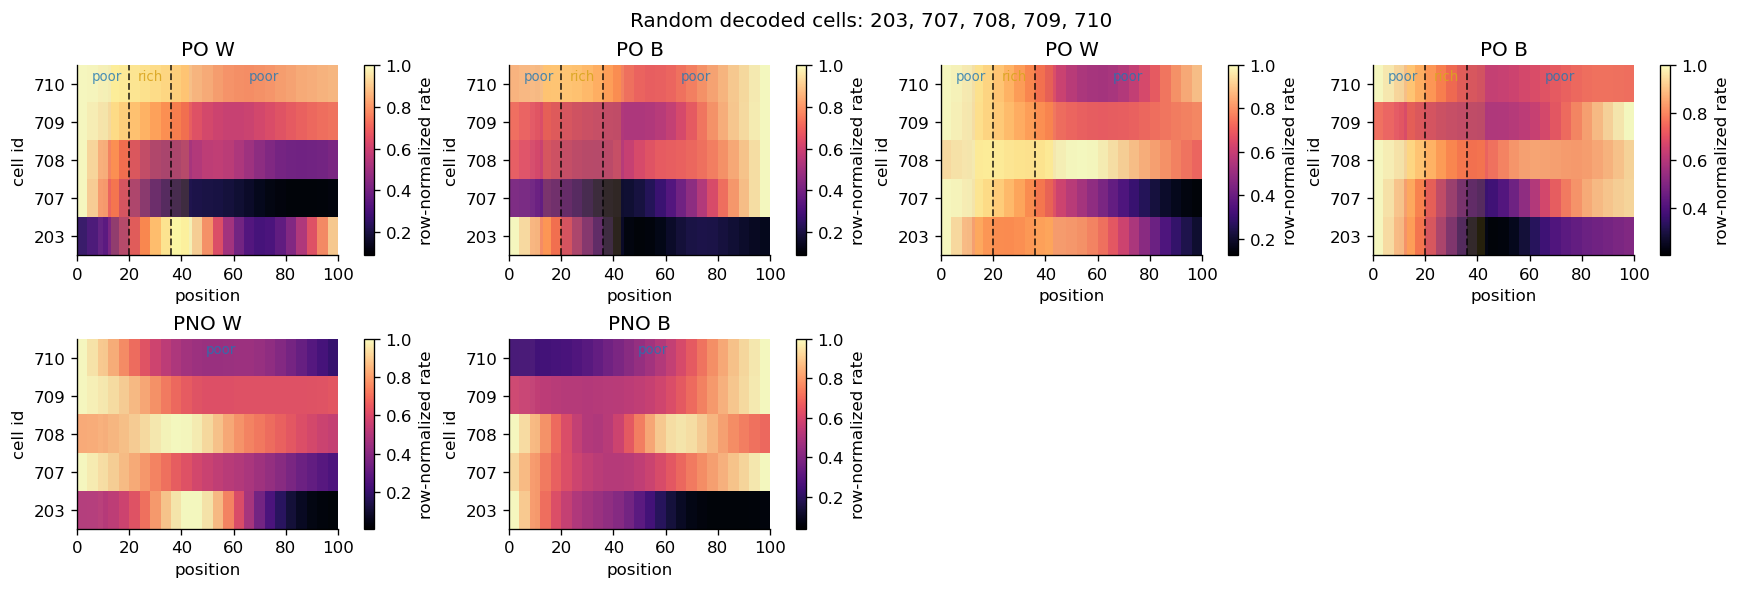

In [30]:
rmap_cfg = RatemapConfig(
    freq_hz=BEHAVIOR_FREQ_HZ,
    smooth_sigma_bins=SMOOTH_SIGMA_BINS,
    xbin_rem=XBIN_REM,
    nb_cond=None,
    min_speed=MIN_SPEED,
)
rmap_pack = build_ratemap_from_trials(
    position_x=context['position_x'],
    spike_indices_0b=context['spike_idx_0b'],
    spike_cell_ids=context['id_spk'],
    cell_ids=result.cell_ids,
    trials=context['trials'],
    xbin_edges=context['xbin_edges_full'],
    cfg=rmap_cfg,
    speed=context['speed'],
)

rng = np.random.default_rng(NEURON_HEATMAP_SEED)
n_show = min(int(N_RANDOM_HEATMAP_CELLS), int(result.cell_ids.size))
selected_cell_ids = np.sort(rng.choice(result.cell_ids, size=n_show, replace=False))
selected_idx = np.array([np.where(rmap_pack.cell_ids == cid)[0][0] for cid in selected_cell_ids], dtype=np.int64)
condways = sorted(set(rmap_pack.idcond_t.astype(int).tolist()))
flip_backward = should_flip_backward_for_context(context, TRACE_FLIP_BACKWARD_FOR_DISPLAY)

n_cols = min(4, len(condways))
n_rows = int(math.ceil(len(condways) / n_cols))
fig, axs = plt.subplots(n_rows, n_cols, figsize=(3.6 * n_cols, 2.4 * n_rows), squeeze=False, constrained_layout=True)

for ax, condway in zip(axs.ravel(), condways):
    maps = rmap_pack.fr_s_cx_ux[selected_idx, int(condway) - 1, :].astype(float)
    if ROW_NORMALIZE_NEURON_HEATMAPS:
        denom = np.nanmax(maps, axis=1, keepdims=True)
        denom[~np.isfinite(denom) | (denom <= 0)] = 1.0
        plot_maps = maps / denom
        cbar_label = 'row-normalized rate'
    else:
        plot_maps = maps
        cbar_label = 'Hz'
    _, direction = decode_condway(int(condway))
    plot_maps = spatial_array_on_common_axis(plot_maps, direction, flip_backward=flip_backward, axis=1)
    im = ax.imshow(
        plot_maps,
        origin='lower',
        aspect='auto',
        interpolation='nearest',
        extent=[rmap_pack.xbin_edges[0], rmap_pack.xbin_edges[-1], -0.5, n_show - 0.5],
        cmap='magma',
    )
    if NORMALIZE_X_TO_100:
        draw_cue_zones_x(ax, cue_layout_for_condway(condway, condition_name_map), show_labels=True)
    ax.set_title(condition_label_for_condway(condway, condition_name_map))
    ax.set_xlabel('position')
    ax.set_yticks(np.arange(n_show))
    ax.set_yticklabels([str(cid) for cid in selected_cell_ids])
    ax.set_ylabel('cell id')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=cbar_label)

for ax in axs.ravel()[len(condways):]:
    ax.axis('off')

fig.suptitle(f"Random decoded cells: {', '.join(map(str, selected_cell_ids.tolist()))}")
plt.show()

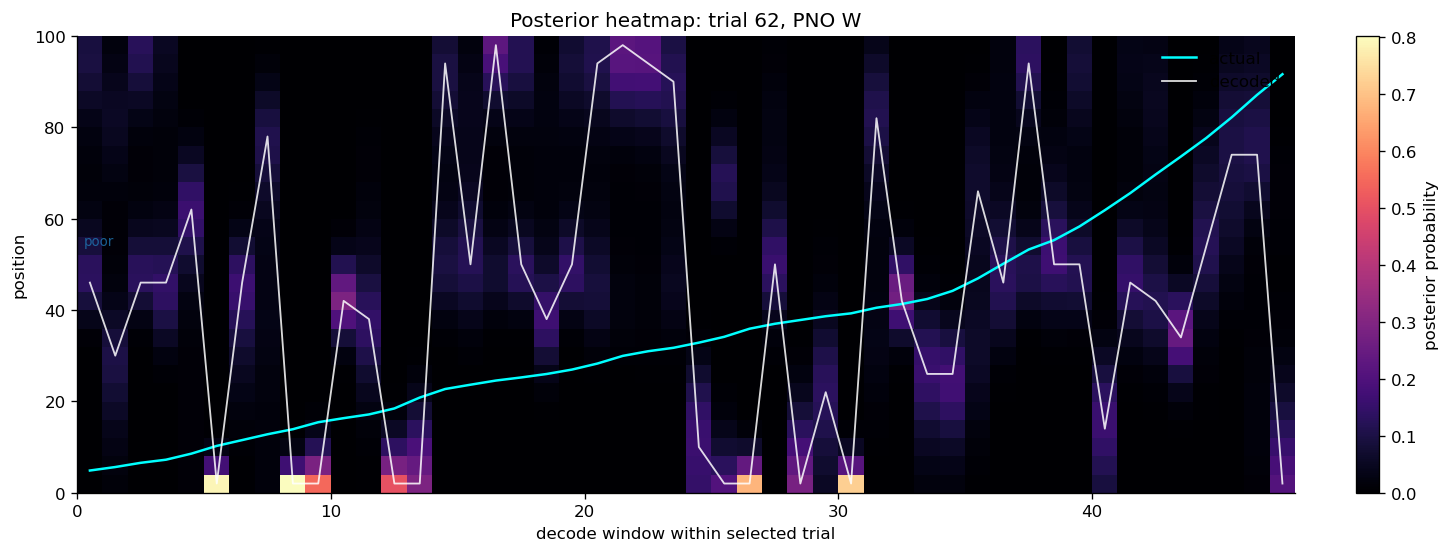

In [31]:
trial_counts = decode_df.groupby('trial_index').size().sort_values(ascending=False)
example_trial = int(trial_counts.index[1])
idx = np.flatnonzero(result.trial_index_w == example_trial)
idx = idx[: min(MAX_POSTERIOR_WINDOWS, idx.size)]

posterior_direction = decode_condway(int(result.condway_w[idx[0]]))[1]
x_min = float(np.nanmin(context['xbin_edges_full']))
x_max = float(np.nanmax(context['xbin_edges_full']))
flip_backward = should_flip_backward_for_context(context, TRACE_FLIP_BACKWARD_FOR_DISPLAY)
posterior = spatial_array_on_common_axis(result.posterior_wx[idx].T, posterior_direction, flip_backward=flip_backward, axis=0)
actual_x_plot = positions_on_common_axis(result.actual_x_w[idx], posterior_direction, x_min=x_min, x_max=x_max, flip_backward=flip_backward)
decoded_x_plot = positions_on_common_axis(result.decoded_x_w[idx], posterior_direction, x_min=x_min, x_max=x_max, flip_backward=flip_backward)
window_axis = np.arange(idx.size) + 0.5

fig, ax = plt.subplots(figsize=(12, 4.5), constrained_layout=True)
im = ax.imshow(
    posterior,
    origin='lower',
    aspect='auto',
    interpolation='nearest',
    extent=[0, idx.size, result.xbin_edges[0], result.xbin_edges[-1]],
    cmap='magma',
)
if NORMALIZE_X_TO_100:
    draw_cue_zones_y(ax, cue_layout_for_condway(int(result.condway_w[idx[0]]), condition_name_map), show_labels=True, style='axis_marker')
ax.plot(window_axis, actual_x_plot, color='cyan', lw=1.5, label='actual')
ax.plot(window_axis, decoded_x_plot, color='white', lw=1.1, alpha=0.85, label='decoded')
posterior_label = condition_label_for_condway(int(result.condway_w[idx[0]]), condition_name_map)
ax.set_title(f'Posterior heatmap: trial {example_trial}, {posterior_label}')
ax.set_xlabel('decode window within selected trial')
ax.set_ylabel('position')
ax.legend(frameon=False, loc='upper right')
fig.colorbar(im, ax=ax, label='posterior probability')
plt.show()

## Best Mean-Error Lap Posterior

This selects the decoded lap with the lowest mean absolute error per decoded window, after requiring at least `MIN_BEST_LAP_WINDOWS` windows. It is a useful best-case sanity check, but it should not replace the pooled error summary above.

,trial_index,condway,condition_label,n_windows,total_abs_error_cm,mean_abs_error_cm,median_abs_error_cm,mean_prob_actual
0,16,1,PO W,21,130.639676,6.220937,4.988457,0.195891
1,13,2,PO B,26,188.677442,7.256825,6.176743,0.182676
2,11,2,PO B,27,202.728119,7.508449,6.892491,0.183460
3,12,1,PO W,26,200.473184,7.710507,4.072740,0.191383
4,38,3,PO W,18,142.983204,7.943511,7.614371,0.127868
5,9,2,PO B,24,213.220957,8.884207,5.960237,0.200533
6,7,2,PO B,26,242.716483,9.335249,7.789460,0.144093
7,29,4,PO B,24,228.758612,9.531609,8.293663,0.150754
8,34,3,PO W,23,232.586226,10.112445,7.035831,0.105902
9,15,2,PO B,24,252.360885,10.515037,5.857348,0.192559


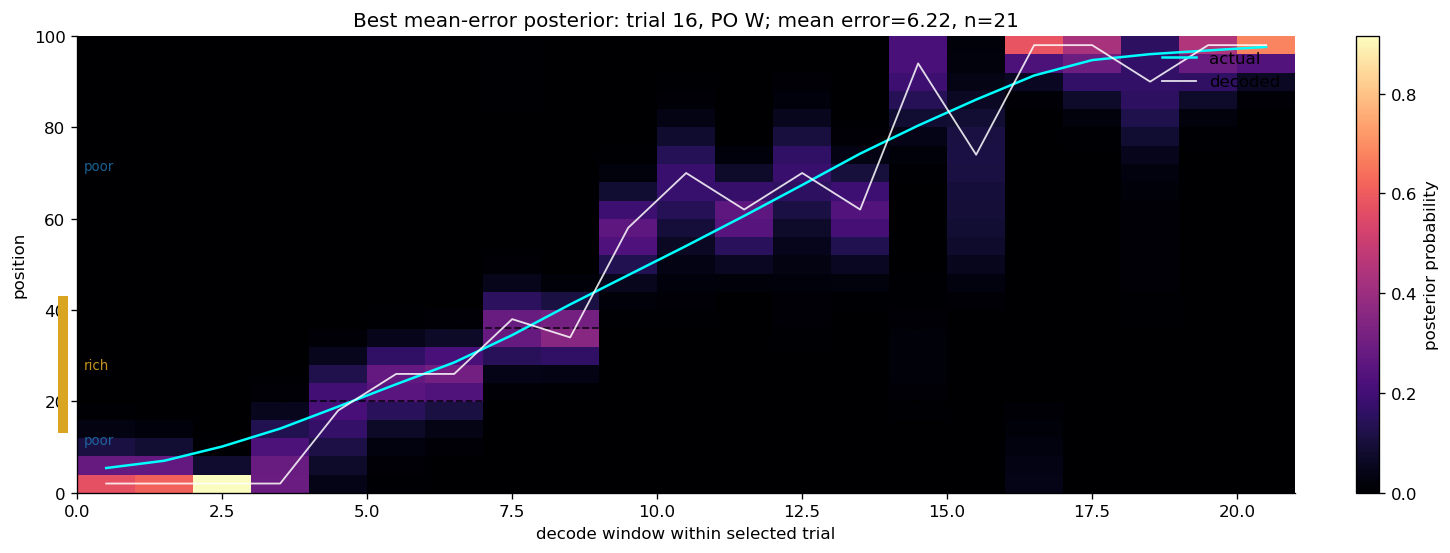

In [32]:
lap_error_df = (
    decode_df.groupby(['trial_index', 'condway', 'condition_label'], sort=False)
    .agg(
        n_windows=('error_cm', 'size'),
        total_abs_error_cm=('error_cm', 'sum'),
        mean_abs_error_cm=('error_cm', 'mean'),
        median_abs_error_cm=('error_cm', 'median'),
        mean_prob_actual=('prob_actual', 'mean'),
    )
    .reset_index()
)
eligible_lap_error_df = lap_error_df[lap_error_df['n_windows'] >= int(MIN_BEST_LAP_WINDOWS)].copy()
if eligible_lap_error_df.empty:
    raise RuntimeError(
        f'No decoded laps have at least {MIN_BEST_LAP_WINDOWS} windows; lower MIN_BEST_LAP_WINDOWS.'
    )

best_lap_row = eligible_lap_error_df.sort_values(
    ['mean_abs_error_cm', 'median_abs_error_cm', 'n_windows'],
    ascending=[True, True, False],
).iloc[0]
display(
    eligible_lap_error_df.sort_values('mean_abs_error_cm')
    .head(10)
    .reset_index(drop=True)
)

best_trial = int(best_lap_row['trial_index'])
idx = np.flatnonzero(result.trial_index_w == best_trial)
idx = idx[np.argsort(result.window_start_w[idx])]
idx = idx[: min(MAX_POSTERIOR_WINDOWS, idx.size)]

posterior_direction = decode_condway(int(result.condway_w[idx[0]]))[1]
x_min = float(np.nanmin(context['xbin_edges_full']))
x_max = float(np.nanmax(context['xbin_edges_full']))
flip_backward = should_flip_backward_for_context(context, TRACE_FLIP_BACKWARD_FOR_DISPLAY)
posterior = spatial_array_on_common_axis(result.posterior_wx[idx].T, posterior_direction, flip_backward=flip_backward, axis=0)
actual_x_plot = positions_on_common_axis(result.actual_x_w[idx], posterior_direction, x_min=x_min, x_max=x_max, flip_backward=flip_backward)
decoded_x_plot = positions_on_common_axis(result.decoded_x_w[idx], posterior_direction, x_min=x_min, x_max=x_max, flip_backward=flip_backward)
window_axis = np.arange(idx.size) + 0.5

fig, ax = plt.subplots(figsize=(12, 4.5), constrained_layout=True)
im = ax.imshow(
    posterior,
    origin='lower',
    aspect='auto',
    interpolation='nearest',
    extent=[0, idx.size, result.xbin_edges[0], result.xbin_edges[-1]],
    cmap='magma',
)
if NORMALIZE_X_TO_100:
    draw_cue_zones_y(ax, cue_layout_for_condway(int(result.condway_w[idx[0]]), condition_name_map), show_labels=True, style='axis_marker')
ax.plot(window_axis, actual_x_plot, color='cyan', lw=1.5, label='actual')
ax.plot(window_axis, decoded_x_plot, color='white', lw=1.1, alpha=0.85, label='decoded')
posterior_label = condition_label_for_condway(int(result.condway_w[idx[0]]), condition_name_map)
ax.set_title(
    f'Best mean-error posterior: trial {best_trial}, {posterior_label}; '
    f'mean error={best_lap_row.mean_abs_error_cm:.2f}, n={int(best_lap_row.n_windows)}'
)
ax.set_xlabel('decode window within selected trial')
ax.set_ylabel('position')
ax.legend(frameon=False, loc='upper right')
fig.colorbar(im, ax=ax, label='posterior probability')
plt.show()

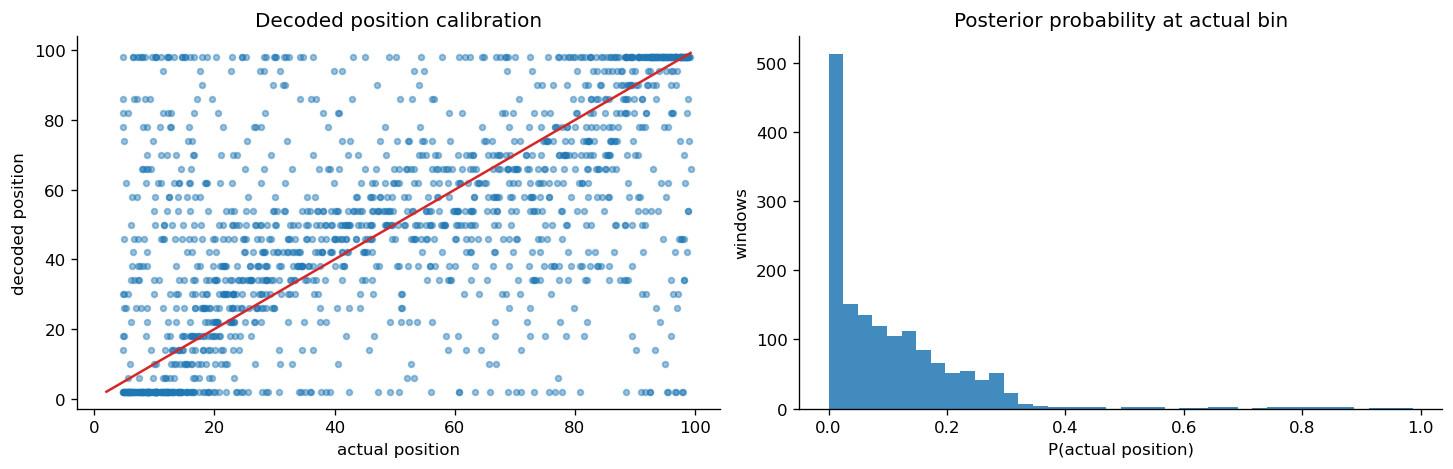

In [33]:
fig, axs = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)

axs[0].scatter(decode_df['actual_x'], decode_df['decoded_x'], s=12, alpha=0.45)
lo = min(decode_df['actual_x'].min(), decode_df['decoded_x'].min())
hi = max(decode_df['actual_x'].max(), decode_df['decoded_x'].max())
axs[0].plot([lo, hi], [lo, hi], color='tab:red', lw=1.5)
axs[0].set_title('Decoded position calibration')
axs[0].set_xlabel('actual position')
axs[0].set_ylabel('decoded position')

axs[1].hist(decode_df['prob_actual'], bins=40, color='tab:blue', alpha=0.85)
axs[1].set_title('Posterior probability at actual bin')
axs[1].set_xlabel('P(actual position)')
axs[1].set_ylabel('windows')

plt.show()

## Decoding error by cue zone across all sessions

The boxes summarize decoded time windows from every Matilde session. Windows whose representative actual position falls in the normalized edge regions `0-13` or `90-100` are excluded rather than labeled cue-poor. Points show the median error within each session. The paired Monte Carlo sign-flip test uses one rich-versus-poor median-error difference per session.


Decoding aggregate session MA104_2021-12-04_19-26-45 (68 cells)
Decoding aggregate session MA104_2021-12-05_21-20-36 (80 cells)
Decoding aggregate session MA104_2021-12-06_22-28-14 (49 cells)
Decoding aggregate session MA105_2021-12-20_18-03-05 (44 cells)
Decoding aggregate session MA105_2021-12-21_18-44-03 (36 cells)
Decoding aggregate session MA106_2022-01-06_21-02-42 (42 cells)


,session_id,cue_zone,n_windows,median_error,mean_error
0,MA104_2021-12-04_19-26-45,poor,765,13.327713,18.660344
1,MA104_2021-12-04_19-26-45,rich,330,9.358514,15.957675
2,MA104_2021-12-05_21-20-36,poor,780,10.652759,16.310590
3,MA104_2021-12-05_21-20-36,rich,265,7.980336,12.174761
4,MA104_2021-12-06_22-28-14,poor,747,13.290272,18.740728
5,MA104_2021-12-06_22-28-14,rich,393,10.838874,18.008861
6,MA105_2021-12-20_18-03-05,poor,866,11.108421,17.033584
7,MA105_2021-12-20_18-03-05,rich,319,6.753231,14.461413
8,MA105_2021-12-21_18-44-03,poor,855,9.909929,16.425572
9,MA105_2021-12-21_18-44-03,rich,319,7.128316,15.674272


,n_sessions,n_windows,median_error,mean_error
cue_zone,,,,
rich,6,2003,7.973458,14.804924
poor,6,5027,11.848847,17.540329


C:\Users\tadse\AppData\Local\Temp\ipykernel_20228\1251095961.py:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(zone_errors, labels=ZONE_ORDER, showfliers=False, patch_artist=True)


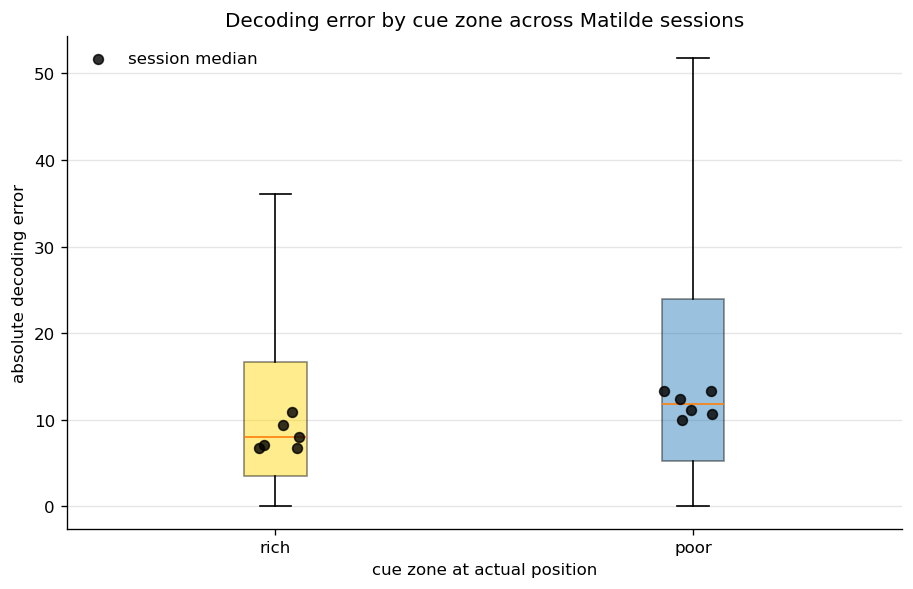

paired sessions: 6
observed mean session median-error difference (poor - rich): 3.6534
Monte Carlo paired sign-flip p-value (two-sided): 0.0314297


cue_zone,poor,rich,poor_minus_rich
session_id,,,
MA106_2022-01-06_21-02-42,12.425979,6.735625,5.690354
MA105_2021-12-20_18-03-05,11.108421,6.753231,4.355190
MA104_2021-12-04_19-26-45,13.327713,9.358514,3.969199
MA105_2021-12-21_18-44-03,9.909929,7.128316,2.781613
MA104_2021-12-05_21-20-36,10.652759,7.980336,2.672423
MA104_2021-12-06_22-28-14,13.290272,10.838874,2.451397


In [34]:
if not NORMALIZE_X_TO_100:
    raise RuntimeError('The aggregate cue-zone plot requires NORMALIZE_X_TO_100=True')

ZONE_ANALYSIS_START = 13.0
ZONE_ANALYSIS_STOP = 90.0
ZONE_ORDER = ['rich', 'poor']


def cue_zone_for_window(actual_x, condway, condition_name_map):
    actual_x = float(actual_x)
    if not np.isfinite(actual_x) or not (ZONE_ANALYSIS_START <= actual_x < ZONE_ANALYSIS_STOP):
        return ''
    layout = cue_layout_for_condway(int(condway), condition_name_map)
    if any(start <= actual_x < stop for start, stop in layout.rich_spans):
        return 'rich'
    return 'poor'


all_session_zone_frames = []
aggregate_failures = []
for session_id, allcel_path, traj_path, n_cells in pairs:
    print(f'Decoding aggregate session {session_id} ({n_cells} cells)')
    try:
        if session_id == context['session_id']:
            session_result, session_context = result, context
        else:
            session_result, session_context = run_decoder_for_pair(session_id, allcel_path, traj_path)
        session_df = result_to_frame(session_result)
        session_df['session_id'] = session_id
        session_df['cue_zone'] = [
            cue_zone_for_window(actual_x, condway, session_context['condition_name_map'])
            for actual_x, condway in zip(session_df['actual_x'], session_df['condway'])
        ]
        session_df = session_df[session_df['cue_zone'].isin(ZONE_ORDER)].copy()
        if not session_df.empty:
            all_session_zone_frames.append(session_df)
    except Exception as exc:
        aggregate_failures.append((session_id, str(exc)))
        print(f'  skipped: {exc}')

if not all_session_zone_frames:
    raise RuntimeError(f'No aggregate cue-zone windows available. Failures: {aggregate_failures}')

all_session_zone_df = pd.concat(all_session_zone_frames, ignore_index=True)
session_zone_summary = (
    all_session_zone_df.groupby(['session_id', 'cue_zone'], sort=True)
    .agg(n_windows=('error_cm', 'size'), median_error=('error_cm', 'median'), mean_error=('error_cm', 'mean'))
    .reset_index()
)
display(session_zone_summary)
display(
    all_session_zone_df.groupby('cue_zone', sort=False)
    .agg(n_sessions=('session_id', 'nunique'), n_windows=('error_cm', 'size'), median_error=('error_cm', 'median'), mean_error=('error_cm', 'mean'))
    .reindex(ZONE_ORDER)
)
if aggregate_failures:
    display(pd.DataFrame(aggregate_failures, columns=['session_id', 'reason']))

zone_errors = [
    all_session_zone_df.loc[all_session_zone_df['cue_zone'] == zone, 'error_cm'].to_numpy()
    for zone in ZONE_ORDER
]
fig, ax = plt.subplots(figsize=(7.5, 4.8), constrained_layout=True)
box = ax.boxplot(zone_errors, labels=ZONE_ORDER, showfliers=False, patch_artist=True)
for patch, color in zip(box['boxes'], ['gold', 'tab:blue']):
    patch.set_facecolor(color)
    patch.set_alpha(0.45)
rng = np.random.default_rng(7)
for x_position, zone in enumerate(ZONE_ORDER, start=1):
    medians = session_zone_summary.loc[session_zone_summary['cue_zone'] == zone, 'median_error'].to_numpy()
    jitter = rng.uniform(-0.07, 0.07, size=medians.size)
    ax.scatter(x_position + jitter, medians, s=34, color='black', alpha=0.8, zorder=3, label='session median' if x_position == 1 else None)
ax.set_title('Decoding error by cue zone across Matilde sessions')
ax.set_xlabel('cue zone at actual position')
ax.set_ylabel('absolute decoding error')
ax.grid(axis='y', color='0.9', lw=0.8)
ax.legend(frameon=False)
plt.show()

paired_session_errors = session_zone_summary.pivot(index='session_id', columns='cue_zone', values='median_error').dropna(subset=ZONE_ORDER)
paired_session_errors['poor_minus_rich'] = paired_session_errors['poor'] - paired_session_errors['rich']
session_deltas = paired_session_errors['poor_minus_rich'].to_numpy(dtype=float)
observed_mean_delta = float(np.mean(session_deltas))
N_SIGN_FLIPS = 100_000
rng = np.random.default_rng(RANDOM_SEED)
signs = rng.choice((-1.0, 1.0), size=(N_SIGN_FLIPS, session_deltas.size))
null_mean_deltas = np.mean(signs * session_deltas[None, :], axis=1)
two_sided_p = float(
    (np.count_nonzero(np.abs(null_mean_deltas) >= abs(observed_mean_delta)) + 1)
    / (N_SIGN_FLIPS + 1)
)
print(f'paired sessions: {session_deltas.size}')
print(f'observed mean session median-error difference (poor - rich): {observed_mean_delta:.4f}')
print(f'Monte Carlo paired sign-flip p-value (two-sided): {two_sided_p:.6g}')
display(paired_session_errors.sort_values('poor_minus_rich', ascending=False))
